# NOTEBOOK: BUSINESS IMPACT ANALYSIS

Sources used:

ADEME (2024)
Techniques de l’Ingénieur
Gomet (2025)

In [2]:
# ============================================================
# ⚠️ DISCLAIMER — COST ASSUMPTIONS
# ============================================================
# All cost values used in this notebook are ESTIMATES
# based on academic and industry literature:
#   - ADEME (2024)
#   - Techniques de l’Ingénieur (2020)
#   - Gomet (2025)
#
# These values are NOT derived from real operational data
# from a wind farm operator. In an industrial context,
# they must be validated with the relevant stakeholders.
# ============================================================

In [3]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [4]:
df_scada=pd.read_csv("df_final.csv")
scada_anomaly=df_scada.copy()
scada_anomaly.head()


,DateTime,Time,Error,WEC: ava. windspeed,WEC: max. windspeed,WEC: min. windspeed,WEC: ava. Rotation,WEC: max. Rotation,WEC: min. Rotation,WEC: ava. Power,...,Control cabinet temp.,Transformer temp.,RTU: ava. Setpoint 1,Inverter averages,Inverter std dev,target,target_30min,target_2h,target_12h,target_24h
0,2014-05-01 00:00:00,1398920448,0,6.9,9.4,2.9,0.0,0.02,0.0,0,...,24,34,2501,25.272728,1.103713,0,0,0,1,1
1,2014-05-01 00:09:00,1398920960,0,5.3,8.9,1.6,0.0,0.01,0.0,0,...,24,34,2501,25.272728,1.103713,0,0,0,1,1
2,2014-05-01 00:20:00,1398921600,0,5.0,9.5,1.4,0.0,0.04,0.0,0,...,24,34,2501,25.272728,1.103713,0,0,0,1,1
3,2014-05-01 00:30:00,1398922240,0,4.4,8.3,1.3,0.0,0.08,0.0,0,...,24,34,2501,25.272728,1.103713,0,0,0,1,1
4,2014-05-01 00:39:00,1398922752,0,5.7,9.7,1.2,0.0,0.05,0.0,0,...,23,34,2501,25.272728,1.103713,0,0,0,1,1


### 1. Context

In [18]:
print("""

Business Impact Analysis: Predictive Maintenance for Wind Turbines

BUSINESS PROBLEM:
─────────────────
Unplanned wind turbine failures generate significant costs:
production losses, emergency interventions, and secondary
damage to components.

MODEL OBJECTIVE:
────────────────
Detect failures 2 hours in advance (although this lead time
may be limited in real operational settings) in order to
enable planned interventions and reduce operating and
maintenance costs (OPEX).

COST SOURCES:
─────────────
- ADEME (2024): onshore wind production costs
- Techniques de l'Ingénieur (2020): wind OPEX
- Gomet (2025): maintenance cost for 4 MW turbines
- Industrial predictive maintenance literature

ASSUMPTIONS:
────────────
All cost values are estimates based on literature.
In a real-world context, these values should be refined
using data from the wind farm operator.

""")



Business Impact Analysis: Predictive Maintenance for Wind Turbines

BUSINESS PROBLEM:
─────────────────
Unplanned wind turbine failures generate significant costs:
production losses, emergency interventions, and secondary
damage to components.

MODEL OBJECTIVE:
────────────────
Detect failures 2 hours in advance (although this lead time
may be limited in real operational settings) in order to
enable planned interventions and reduce operating and
maintenance costs (OPEX).

COST SOURCES:
─────────────
- ADEME (2024): onshore wind production costs
- Techniques de l'Ingénieur (2020): wind OPEX
- Gomet (2025): maintenance cost for 4 MW turbines
- Industrial predictive maintenance literature

ASSUMPTIONS:
────────────
All cost values are estimates based on literature.
In a real-world context, these values should be refined
using data from the wind farm operator.




### 2. Technical Parameters (From Sources)

In [6]:

# --- Caractéristiques techniques (source : ADEME / Gomet 2025)
params = {
    'puissance_MW'          : 4,      # MW — éolienne terrestre standard
    'facteur_charge'        : 0.25,   # 25% en France (éolien terrestre)
    'prix_MWh'              : 60,     # €/MWh — appels d'offres France 2024
    'heures_an'             : 8760,   # heures/an
    'maintenance_MW_an'     : 45000,  # €/MW/an (fourchette 40-50k) car 5 000€ - 25 000€ ca peut etre pour une seule intervention
}

# --- Production et revenus
params['production_MWh_h'] = params['puissance_MW'] * params['facteur_charge']
params['revenu_h']         = params['production_MWh_h'] * params['prix_MWh']
params['maintenance_an']   = params['maintenance_MW_an'] * params['puissance_MW']
params['maintenance_h']    = params['maintenance_an'] / params['heures_an']

print("─" * 50)
print("  PARAMÈTRES TECHNIQUES DE L'ÉOLIENNE")
print("─" * 50)
print(f"  Puissance installée     : {params['puissance_MW']} MW")
print(f"  Facteur de charge       : {params['facteur_charge']*100:.0f}%")
print(f"  Prix électricité        : {params['prix_MWh']} €/MWh")
print(f"  Production moyenne      : {params['production_MWh_h']} MWh/heure")
print(f"  Revenu horaire          : {params['revenu_h']:.0f} €/heure")
print(f"  Maintenance annuelle    : {params['maintenance_an']:,} €/an")

──────────────────────────────────────────────────
  PARAMÈTRES TECHNIQUES DE L'ÉOLIENNE
──────────────────────────────────────────────────
  Puissance installée     : 4 MW
  Facteur de charge       : 25%
  Prix électricité        : 60 €/MWh
  Production moyenne      : 1.0 MWh/heure
  Revenu horaire          : 60 €/heure
  Maintenance annuelle    : 180,000 €/an


In [7]:
scada_anomaly.head()

,DateTime,Time,Error,WEC: ava. windspeed,WEC: max. windspeed,WEC: min. windspeed,WEC: ava. Rotation,WEC: max. Rotation,WEC: min. Rotation,WEC: ava. Power,...,Control cabinet temp.,Transformer temp.,RTU: ava. Setpoint 1,Inverter averages,Inverter std dev,target,target_30min,target_2h,target_12h,target_24h
0,2014-05-01 00:00:00,1398920448,0,6.9,9.4,2.9,0.0,0.02,0.0,0,...,24,34,2501,25.272728,1.103713,0,0,0,1,1
1,2014-05-01 00:09:00,1398920960,0,5.3,8.9,1.6,0.0,0.01,0.0,0,...,24,34,2501,25.272728,1.103713,0,0,0,1,1
2,2014-05-01 00:20:00,1398921600,0,5.0,9.5,1.4,0.0,0.04,0.0,0,...,24,34,2501,25.272728,1.103713,0,0,0,1,1
3,2014-05-01 00:30:00,1398922240,0,4.4,8.3,1.3,0.0,0.08,0.0,0,...,24,34,2501,25.272728,1.103713,0,0,0,1,1
4,2014-05-01 00:39:00,1398922752,0,5.7,9.7,1.2,0.0,0.05,0.0,0,...,23,34,2501,25.272728,1.103713,0,0,0,1,1


In [8]:
# Calculer la durée réelle des pannes dans VOS données
pannes = scada_anomaly[scada_anomaly['target'] == 1].copy()
pannes = pannes.sort_values('DateTime')
pannes['DateTime']=pd.to_datetime(pannes['DateTime'])

# Regrouper les pannes consécutives
pannes['groupe'] = (
    pannes['DateTime'].diff() > pd.Timedelta(hours=1)
).cumsum()

durees = pannes.groupby('groupe')['DateTime'].agg(
    debut='min', fin='max'
)
durees['duree_h'] = (
    durees['fin'] - durees['debut']
).dt.total_seconds() / 3600

# ✅ Distinguer pannes courtes vs longues
pannes_courtes = (durees['duree_h'] < 1).sum()
pannes_longues = (durees['duree_h'] >= 1).sum()
ratio_long     = pannes_longues / len(durees)
ratio_court    = 1 - ratio_long

print(durees[['debut', 'fin', 'duree_h']])
print(f"\nDurée moyenne  : {durees['duree_h'].mean():.1f}h")
print(f"Durée médiane  : {durees['duree_h'].median():.1f}h")
print(f"Durée max      : {durees['duree_h'].max():.1f}h")
print(f"Durée min      : {durees['duree_h'].min():.1f}h")
print(f"\nPannes courtes (<1h)  : {pannes_courtes} ({ratio_court*100:.0f}%)")
print(f"Pannes longues (>=1h) : {pannes_longues} ({ratio_long*100:.0f}%)")


                     debut                 fin    duree_h
groupe                                                   
0      2014-05-01 11:29:00 2014-05-01 11:29:00   0.000000
1      2014-05-15 09:41:00 2014-05-15 09:41:00   0.000000
2      2014-05-15 11:49:00 2014-05-15 11:49:00   0.000000
3      2014-05-27 11:00:00 2014-05-27 11:00:00   0.000000
4      2014-06-04 08:20:00 2014-06-04 08:20:00   0.000000
5      2014-06-04 17:00:00 2014-06-04 17:00:00   0.000000
6      2014-06-05 17:41:00 2014-06-05 17:41:00   0.000000
7      2014-06-13 12:50:00 2014-06-13 13:10:00   0.333333
8      2014-07-10 13:29:00 2014-07-10 15:50:00   2.350000
9      2014-07-10 17:19:00 2014-07-10 17:38:00   0.316667
10     2014-07-11 08:30:00 2014-07-11 10:10:00   1.666667
11     2014-07-17 10:19:00 2014-07-17 10:19:00   0.000000
12     2014-09-03 14:39:00 2014-09-03 14:39:00   0.000000
13     2014-09-03 15:50:00 2014-09-03 15:50:00   0.000000
14     2014-09-26 14:09:00 2014-09-26 14:09:00   0.000000
15     2014-09

### 3. Define the Cost

In [9]:
# --- Coût panne NON détectée (Faux Négatif) => intervention non-planifiée
# Source : littérature maintenance éolienne
couts_FN_long = {
    'perte_production'    : params['revenu_h'] * 48,  # 48h arrêt logistique non planifié
    'intervention_urgence': 8_000,                    # surcoût vs intervention planifiée
    'pieces_urgence'      : 5_000,                    # surcoût commande pièces urgence
    'dommages_secondaires': 3_000,                    # dégâts composants adjacents
}
couts_FN_court = {
    'perte_production'    : params['revenu_h'] * 4,   # 4h arrêt alarme ponctuelle
    'intervention_urgence': 1_500,                    # déplacement technicien
    'pieces_urgence'      : 500,                      # diagnostic simple
    'dommages_secondaires': 200,                      # faible car panne courte
}

COUT_FN_long  = sum(couts_FN_long.values())
COUT_FN_court = sum(couts_FN_court.values())


#********************************************************************************************************#
# 1. Durée moyenne panne dans les données réelles
COUT_FN = (ratio_long * COUT_FN_long) + (ratio_court * COUT_FN_court)

couts_FP = {
    'arret_preventif'  : params['revenu_h'] * 4,  # 4h arrêt préventif inutile
    'deplacement_tech' : 800,                      # déplacement + main d'oeuvre
    'diagnostic_inutile': 400,                     # temps technicien
}
COUT_FP = sum(couts_FP.values())

print(f"\n{'─'*50}")
print(f"  COÛTS UNITAIRES")
print(f"{'─'*50}")
print(f"\n  Panne longue (>=1h) NON détectée :")
for k, v in couts_FN_long.items():
    print(f"    {k:<25} : {v:>8,} €")
print(f"    {'TOTAL FN long':<25} : {COUT_FN_long:>8,} €")

print(f"\n  Panne courte (<1h) NON détectée :")
for k, v in couts_FN_court.items():
    print(f"    {k:<25} : {v:>8,} €")
print(f"    {'TOTAL FN court':<25} : {COUT_FN_court:>8,} €")

print(f"\n  Coût FN moyen pondéré     : {COUT_FN:>8,.0f} €")

print(f"\n  Fausse alarme (FP) :")
for k, v in couts_FP.items():
    print(f"    {k:<25} : {v:>8,} €")
print(f"    {'TOTAL FP':<25} : {COUT_FP:>8,} €")


──────────────────────────────────────────────────
  COÛTS UNITAIRES
──────────────────────────────────────────────────

  Panne longue (>=1h) NON détectée :
    perte_production          :  2,880.0 €
    intervention_urgence      :    8,000 €
    pieces_urgence            :    5,000 €
    dommages_secondaires      :    3,000 €
    TOTAL FN long             : 18,880.0 €

  Panne courte (<1h) NON détectée :
    perte_production          :    240.0 €
    intervention_urgence      :    1,500 €
    pieces_urgence            :      500 €
    dommages_secondaires      :      200 €
    TOTAL FN court            :  2,440.0 €

  Coût FN moyen pondéré     :    6,176 €

  Fausse alarme (FP) :
    arret_preventif           :    240.0 €
    deplacement_tech          :      800 €
    diagnostic_inutile        :      400 €
    TOTAL FP                  :  1,440.0 €


### 4. Model Performance


In [10]:
df_binary = scada_anomaly[scada_anomaly['target_2h'].isin([0, 1])].copy()
scada_anomaly = df_binary.copy()

scada_anomaly_numeric = scada_anomaly.select_dtypes(include=[np.number])
features = []
for col in scada_anomaly_numeric.columns:
    if col not in ['target', 'target_failure', 'target_30min',
                   'target_12h', 'target_2h', 'target_24h',
                   'Error', 'DateTime', 'Time']:
        features.append(col)
print(f"   Features sélectionnées : {len(features)}")

X = scada_anomaly[features].fillna(0)
y = scada_anomaly['target_2h']

# ✅ Split temporel
split_idx = int(len(scada_anomaly) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"   Train : {len(X_train)} | Test : {len(X_test)}")

   Features sélectionnées : 63
   Train : 34318 | Test : 14709


In [11]:
split_idx=int(len(scada_anomaly)*0.7)

X_train, X_test=X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test=y.iloc[:split_idx], y.iloc[split_idx:]

print(f"train : {len(X_train)}, test : {len(X_test)} ")


train : 34318, test : 14709 


In [19]:
model  = joblib.load('best_model_final.pkl')
scaler = joblib.load('scaler_final.pkl')

# ✅ transform seulement — pas fit
X_test_scaled = scaler.transform(X_test)

y_proba     = model.predict_proba(X_test_scaled)[:, 1]
SEUIL_FINAL = 0.4
y_pred      = (y_proba >= SEUIL_FINAL).astype(int)

cm             = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
nb_jours_test  = len(y_test) * 10 / 60 / 24

print(f"  MODEL PERFORMANCE (threshold = {SEUIL_FINAL})")
print("─" * 50)
print(f"  Test period           : {nb_jours_test:.0f} days")
print(f"  Actual failures       : {TP + FN}")
print(f"  Detected failures (TP): {TP}")
print(f"  Missed failures  (FN) : {FN}")
print(f"  False alarms    (FP)  : {FP}")
print(f"  True negatives  (TN)  : {TN}")

print(f"\n{classification_report(y_test, y_pred, target_names=['Normal','Failure'])}")


  MODEL PERFORMANCE (threshold = 0.4)
──────────────────────────────────────────────────
  Test period           : 102 days
  Actual failures       : 407
  Detected failures (TP): 238
  Missed failures  (FN) : 169
  False alarms    (FP)  : 199
  True negatives  (TN)  : 14103

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     14302
     Failure       0.54      0.58      0.56       407

    accuracy                           0.97     14709
   macro avg       0.77      0.79      0.78     14709
weighted avg       0.98      0.97      0.98     14709



In [21]:
nb_pannes_total  = TP + FN
economie_TP      = TP * COUT_FN
cout_FN_total    = FN * COUT_FN
cout_FP_total    = FP * COUT_FP

cout_sans_modele = nb_pannes_total * COUT_FN
cout_avec_modele = cout_FN_total + cout_FP_total
economie_brute   = cout_sans_modele - cout_avec_modele
reduction_pct    = (economie_brute / cout_sans_modele) * 100

print(f"\n{'═'*55}")
print(f"  FINANCIAL SUMMARY — {nb_jours_test:.0f} DAYS OF TEST")
print(f"{'═'*55}")
print(f"  WITHOUT MODEL SCENARIO  : {cout_sans_modele:>12,.0f} €")
print(f"  WITH MODEL SCENARIO     : {cout_avec_modele:>12,.0f} €")
print(f"    of which FN           : {cout_FN_total:>12,.0f} €")
print(f"    of which FP           : {cout_FP_total:>12,.0f} €")
print(f"  {'─'*45}")
print(f"  GROSS SAVINGS           : {economie_brute:>12,.0f} €")
print(f"  COST REDUCTION         : {reduction_pct:>11.1f} %")



═══════════════════════════════════════════════════════
  FINANCIAL SUMMARY — 102 DAYS OF TEST
═══════════════════════════════════════════════════════
  WITHOUT MODEL SCENARIO  :    2,513,780 €
  WITH MODEL SCENARIO     :    1,330,365 €
    of which FN           :    1,043,805 €
    of which FP           :      286,560 €
  ─────────────────────────────────────────────
  GROSS SAVINGS           :    1,183,415 €
  COST REDUCTION         :        47.1 %


### 5. Financial Evaluation Over the Test Period

In [22]:
factor_annual = 365 / nb_jours_test
annual_savings = economie_brute * factor_annual

project_costs = {
    'model_development': 15_000,
    'deployment'       :  5_000,
    'annual_maintenance':  3_000,
    'team_training'    :  2_000,
}
TOTAL_PROJECT_COST = sum(project_costs.values())

print(f"\n{'═'*55}")
print(f"  ANNUAL PROJECTION & ROI")
print(f"{'═'*55}")
print(f"  Estimated annual savings : {annual_savings:>10,.0f} €")
print(f"\n  Project cost breakdown:")
for k, v in project_costs.items():
    print(f"    {k:<28} : {v:>8,} €")
print(f"    {'TOTAL PROJECT COST':<28} : {TOTAL_PROJECT_COST:>8,} €")

print(f"\n  CUMULATED ROI:")
roi = -TOTAL_PROJECT_COST
for year in range(1, 4):
    roi += annual_savings - project_costs['annual_maintenance']
    status = "✅" if roi >= 0 else "❌"
    print(f"    Year {year} : {roi:>12,.0f} € {status}")

print(f"\n  RETURN ON INVESTMENT : "
      f"{annual_savings / TOTAL_PROJECT_COST:.1f}x per year")


═══════════════════════════════════════════════════════
  ANNUAL PROJECTION & ROI
═══════════════════════════════════════════════════════
  Estimated annual savings :  4,228,722 €

  Project cost breakdown:
    model_development            :   15,000 €
    deployment                   :    5,000 €
    annual_maintenance           :    3,000 €
    team_training                :    2,000 €
    TOTAL PROJECT COST           :   25,000 €

  CUMULATED ROI:
    Year 1 :    4,200,722 € ✅
    Year 2 :    8,426,444 € ✅
    Year 3 :   12,652,165 € ✅

  RETURN ON INVESTMENT : 169.1x per year


Text(1.35, 1922072.7272727273, '-47%\n(1,183,415 € saved)')

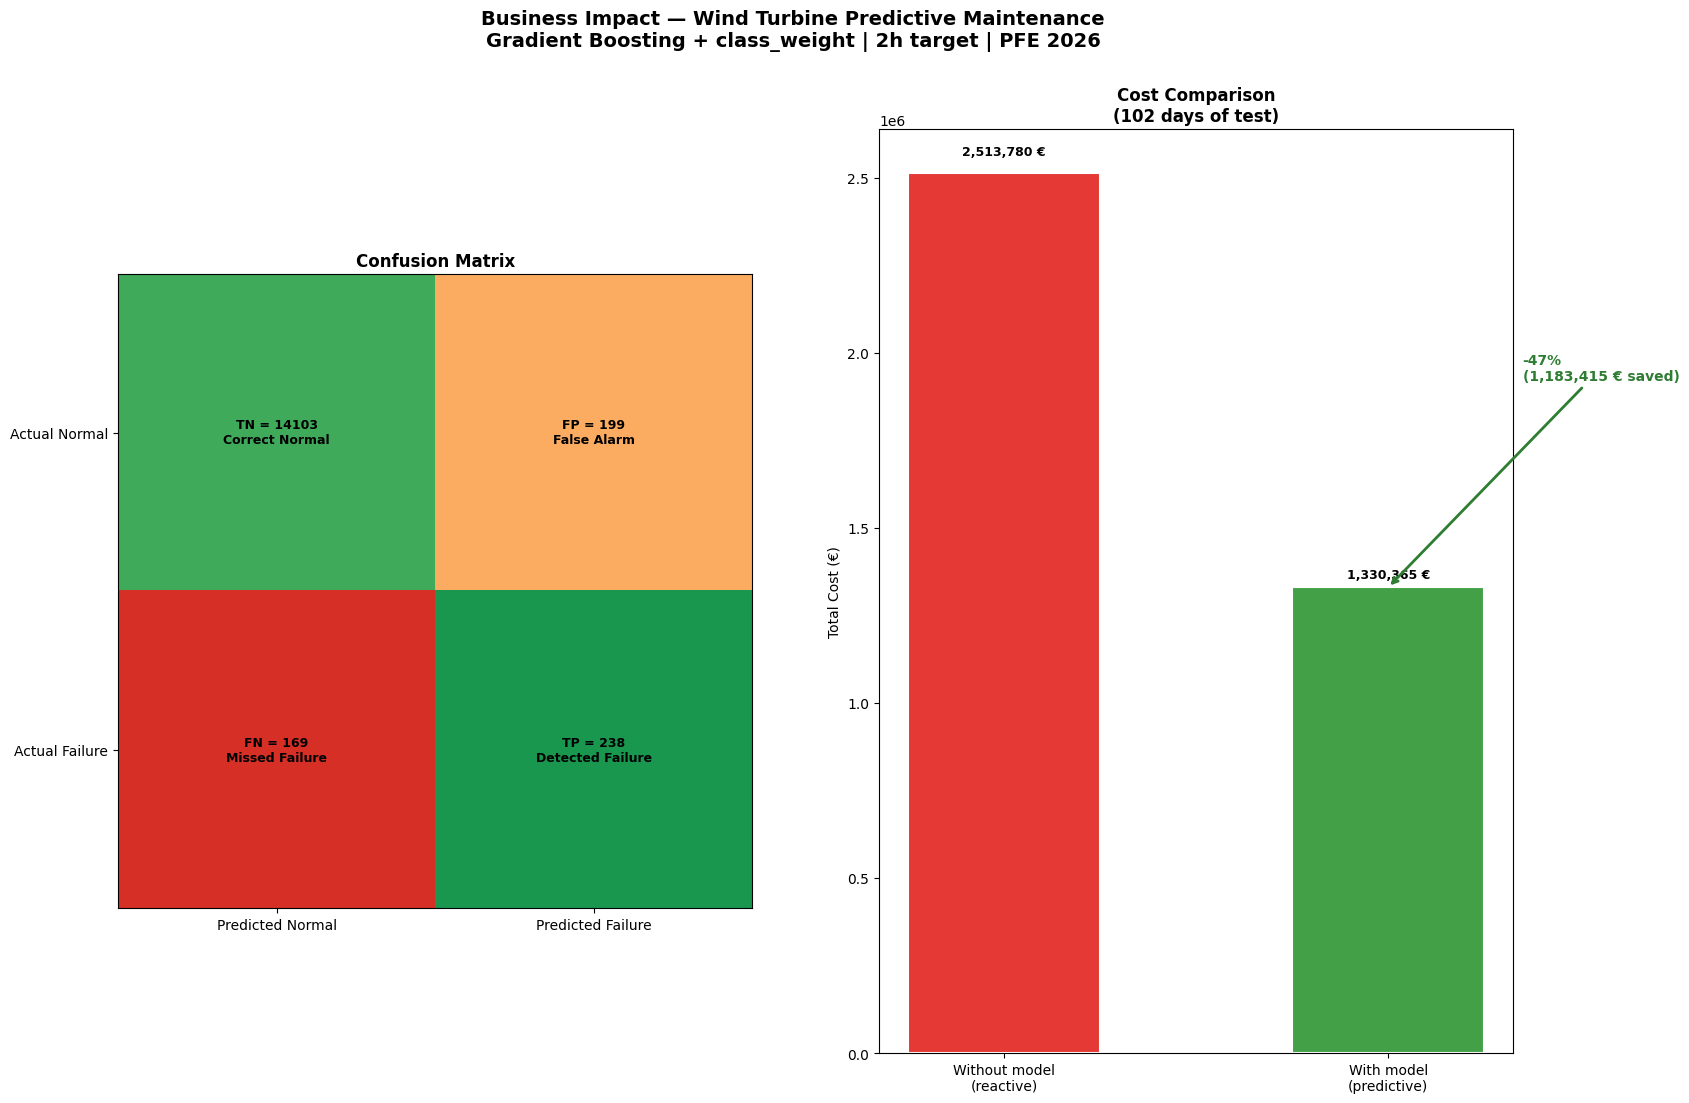

In [23]:
# ── Plot 1: Annotated Confusion Matrix ──

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    "Business Impact — Wind Turbine Predictive Maintenance\n"
    "Gradient Boosting + class_weight | 2h target | PFE 2026",
    fontsize=14, fontweight='bold', y=0.98
)

# ── Graph 1: Confusion Matrix ──
ax1 = fig.add_subplot(1, 2, 1)

cm_display = np.array([[TN, FP], [FN, TP]])
colors_cm  = np.array([[0.85, 0.3], [0.1, 0.9]])

im = ax1.imshow(colors_cm, cmap='RdYlGn', vmin=0, vmax=1)

labels_cm = [
    [f'TN = {TN}\nCorrect Normal',   f'FP = {FP}\nFalse Alarm'],
    [f'FN = {FN}\nMissed Failure',   f'TP = {TP}\nDetected Failure']
]

for i in range(2):
    for j in range(2):
        ax1.text(j, i, labels_cm[i][j],
                 ha='center', va='center',
                 fontsize=9, fontweight='bold')

ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])

ax1.set_xticklabels(['Predicted Normal', 'Predicted Failure'])
ax1.set_yticklabels(['Actual Normal', 'Actual Failure'])

ax1.set_title('Confusion Matrix', fontweight='bold')


# ── Graph 2: Cost Comparison ──
ax2 = fig.add_subplot(1, 2, 2)

categories = ['Without model\n(reactive)', 'With model\n(predictive)']
values     = [cout_sans_modele, cout_avec_modele]
colors_bar = ['#E53935', '#43A047']

bars = ax2.bar(categories, values,
               color=colors_bar,
               width=0.5,
               edgecolor='white',
               linewidth=1.5)

ax2.set_ylabel('Total Cost (€)')
ax2.set_title(f'Cost Comparison\n({nb_jours_test:.0f} days of test)',
              fontweight='bold')

for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.02,
             f'{val:,.0f} €',
             ha='center',
             fontsize=9,
             fontweight='bold')

ax2.annotate(
    f'-{reduction_pct:.0f}%\n({economie_brute:,.0f} € saved)',
    xy=(1, cout_avec_modele),
    xytext=(1.35, (cout_sans_modele + cout_avec_modele) / 2),
    fontsize=10,
    color='#2E7D32',
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2)
)

### 6. Annual Projection & ROI ──


In [25]:
# ── 6. Annual Projection & ROI ──

factor_annual = 365 / nb_jours_test
annual_savings = economie_brute * factor_annual

# Project costs (PFE estimates)
project_costs = {
    'model_development' : 15_000,
    'deployment'        : 5_000,
    'annual_maintenance': 3_000,
    'team_training'     : 2_000,
}
TOTAL_PROJECT_COST = sum(project_costs.values())

# Cumulative ROI over 3 years
roi_cumulative = []

for year in range(4):
    if year == 0:
        roi_cumulative.append(-TOTAL_PROJECT_COST)
    else:
        previous_roi = roi_cumulative[-1]
        roi_cumulative.append(
            previous_roi + annual_savings - project_costs['annual_maintenance']
        )

print(f"\n{'═'*55}")
print(f"  ANNUAL PROJECTION & ROI")
print(f"{'═'*55}")
print(f"  Estimated annual savings : {annual_savings:>10,.0f} €")

print(f"\n  Project cost breakdown:")
for k, v in project_costs.items():
    print(f"    {k:<28} : {v:>8,} €")

print(f"    {'TOTAL PROJECT COST':<28} : {TOTAL_PROJECT_COST:>8,} €")

print(f"\n  CUMULATIVE ROI:")
for i, roi in enumerate(roi_cumulative):
    status = "OK" if roi >= 0 else "Not yet profitable"
    print(f"    Year {i} : {roi:>10,.0f} € {status}")

print(f"\n  RETURN ON INVESTMENT : "
      f"{annual_savings / TOTAL_PROJECT_COST:.1f}x per year")


═══════════════════════════════════════════════════════
  ANNUAL PROJECTION & ROI
═══════════════════════════════════════════════════════
  Estimated annual savings :  4,228,722 €

  Project cost breakdown:
    model_development            :   15,000 €
    deployment                   :    5,000 €
    annual_maintenance           :    3,000 €
    team_training                :    2,000 €
    TOTAL PROJECT COST           :   25,000 €

  CUMULATIVE ROI:
    Year 0 :    -25,000 € Not yet profitable
    Year 1 :  4,200,722 € OK
    Year 2 :  8,426,444 € OK
    Year 3 : 12,652,165 € OK

  RETURN ON INVESTMENT : 169.1x per year
